<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/***Municipality%20Merge%20(ps01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [2]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [3]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [4]:
#NJ Office of GIS (March 14, 2025), Municipal Boundaries of NJ, Hosted, 3857
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::municipal-boundaries-of-nj-hosted-3857/about)
#code used from class
! wget -q -O Municipalities.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Municipalities.zip

zip_ref = zipfile.ZipFile('Municipalities.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njMun=gpd.read_file('Municipalities.shp') #labeled shapefile njSch
#With the school district shapefile made with municipalities in mind and doesn't include all school districts when merging, a municipality shape file was used.

<Axes: >

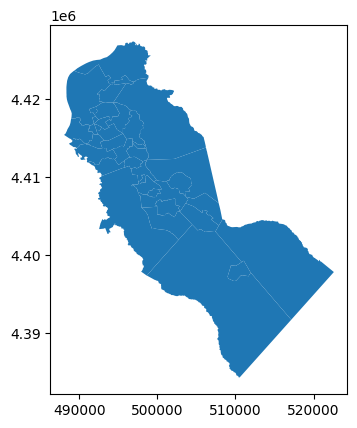

In [5]:
njMun.plot()

In [6]:
njMun.head(2)

,FID,COUSUBNS,GEOID,NAMELSAD,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,GEOCODE,GlobalID,Shape__Are,Shape__Len,geometry
0,1,00885144,3400702200,Audubon borough,C5,F,3838781,35535,+39.8901277,-75.0723825,9407.757950,3400702200,81d661c6-35a7-42ed-8afd-5f35d0b0e807,3.871214e+06,9407.757866,"POLYGON ((495599.23 4415536.249, 495508.749 44..."
1,2,00885145,3400702230,Audubon Park borough,C5,F,389606,46935,+39.8968373,-75.0888190,2734.677596,3400702230,f8ccbea8-76dd-44e7-992b-e367d22e31a1,4.361934e+05,2734.677499,"POLYGON ((492866.221 4416337.872, 492855.687 4..."


In [7]:
njMun.rename(columns={'NAMELSAD' : 'District'}, inplace=True)
njMun['District'] = njMun['District'].str.upper()
njMun1 = njMun[['District','GEOID']]

In [8]:
njMun.rename(columns={'NAMELSAD' : 'District'}, inplace=True)
njMun['District'] = njMun['District'].str.upper()
njMun1 = njMun[['District','GEOID']]
njMun1

,District,GEOID
0,AUDUBON BOROUGH,3400702200
1,AUDUBON PARK BOROUGH,3400702230
2,BARRINGTON BOROUGH,3400703250
3,BELLMAWR BOROUGH,3400704750
4,BERLIN BOROUGH,3400705440
5,BERLIN TOWNSHIP,3400705470
6,BROOKLAWN BOROUGH,3400708170
7,CAMDEN CITY,3400710000
8,CHERRY HILL TOWNSHIP,3400712280
9,CHESILHURST BOROUGH,3400712550


In [9]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/State%20Economically%20Disadvantage%20Youth.xlsx', header = 3)

In [10]:
DisXls1=DisXls[DisXls['SchoolYear'] =='2024-25'][['CountyName','DistrictCode','DistrictName','Economically Disadvantaged Students']]
DisXls1.rename(columns={'DistrictName' : 'District'}, inplace=True)
DisXls1['District'] = DisXls1['District'].str.upper()
DisXls1

,CountyName,DistrictCode,District,Economically Disadvantaged Students
4,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%
9,Camden,190,BARRINGTON SCHOOL DISTRICT,34.1%
14,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%
19,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,25.2%
24,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%
29,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%
34,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%
39,Camden,680,CAMDEN CITY SCHOOL DISTRICT,88.5%
44,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%
49,Camden,800,CHERRY HILL SCHOOL DISTRICT,23.2%


In [11]:
#njMun1[['MUN','GEOID']]
#code from class to strip white space for merging
DisXls1['c']=DisXls1.District.str.strip()
njMun1['c']=njMun1.District.str.strip()

/tmp/ipykernel_2229/3087237768.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  njMun1['c']=njMun1.District.str.strip()


In [12]:
#code from Gemini to make all upper case for merging
DisXls1['District'] = DisXls1['District'].str.upper()
njMun1['District'] = njMun1['District'].str.upper()
njMun1['first_word_District'] = njMun1['District'].str.split().str[0]

/tmp/ipykernel_2229/305046837.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  njMun1['District'] = njMun1['District'].str.upper()
/tmp/ipykernel_2229/305046837.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  njMun1['first_word_District'] = njMun1['District'].str.split().str[0]


In [13]:
#code from Gemini to match only the first word which is the name of the school and municipality
DisXls1['first_word_District'] = DisXls1['District'].str.split().str[0]

In [14]:
DisXls1

,CountyName,DistrictCode,District,Economically Disadvantaged Students,c,first_word_District
4,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,AUDUBON PUBLIC SCHOOL DISTRICT,AUDUBON
9,Camden,190,BARRINGTON SCHOOL DISTRICT,34.1%,BARRINGTON SCHOOL DISTRICT,BARRINGTON
14,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%,BELLMAWR PUBLIC SCHOOL DISTRICT,BELLMAWR
19,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,BERLIN BOROUGH SCHOOL DISTRICT,BERLIN
24,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,BERLIN TOWNSHIP SCHOOL DISTRICT,BERLIN
29,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,BLACK
34,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%,BROOKLAWN PUBLIC SCHOOL DISTRICT,BROOKLAWN
39,Camden,680,CAMDEN CITY SCHOOL DISTRICT,88.5%,CAMDEN CITY SCHOOL DISTRICT,CAMDEN
44,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,CAMDEN
49,Camden,800,CHERRY HILL SCHOOL DISTRICT,23.2%,CHERRY HILL SCHOOL DISTRICT,CHERRY


In [15]:
#merged newly created column "first_word_MUN", MUN and Camden County
a1 = pd.merge(njMun1, DisXls1, left_on=['first_word_District'], right_on=['first_word_District'], how='outer', indicator=True)
a1

,District_x,GEOID,c_x,first_word_District,CountyName,DistrictCode,District_y,Economically Disadvantaged Students,c_y,_merge
0,AUDUBON BOROUGH,3400702200,AUDUBON BOROUGH,AUDUBON,Camden,150.0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,AUDUBON PUBLIC SCHOOL DISTRICT,both
1,AUDUBON PARK BOROUGH,3400702230,AUDUBON PARK BOROUGH,AUDUBON,Camden,150.0,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,AUDUBON PUBLIC SCHOOL DISTRICT,both
2,BARRINGTON BOROUGH,3400703250,BARRINGTON BOROUGH,BARRINGTON,Camden,190.0,BARRINGTON SCHOOL DISTRICT,34.1%,BARRINGTON SCHOOL DISTRICT,both
3,BELLMAWR BOROUGH,3400704750,BELLMAWR BOROUGH,BELLMAWR,Camden,260.0,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%,BELLMAWR PUBLIC SCHOOL DISTRICT,both
4,BERLIN BOROUGH,3400705440,BERLIN BOROUGH,BERLIN,Camden,330.0,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,BERLIN BOROUGH SCHOOL DISTRICT,both
5,BERLIN BOROUGH,3400705440,BERLIN BOROUGH,BERLIN,Camden,340.0,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,BERLIN TOWNSHIP SCHOOL DISTRICT,both
6,BERLIN TOWNSHIP,3400705470,BERLIN TOWNSHIP,BERLIN,Camden,330.0,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,BERLIN BOROUGH SCHOOL DISTRICT,both
7,BERLIN TOWNSHIP,3400705470,BERLIN TOWNSHIP,BERLIN,Camden,340.0,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,BERLIN TOWNSHIP SCHOOL DISTRICT,both
8,NaN,NaN,NaN,BLACK,Camden,390.0,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,right_only
9,BROOKLAWN BOROUGH,3400708170,BROOKLAWN BOROUGH,BROOKLAWN,Camden,580.0,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%,BROOKLAWN PUBLIC SCHOOL DISTRICT,both


In [16]:
a1._merge.value_counts()

,count
_merge,
both,40
right_only,9
left_only,4


<Axes: >

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

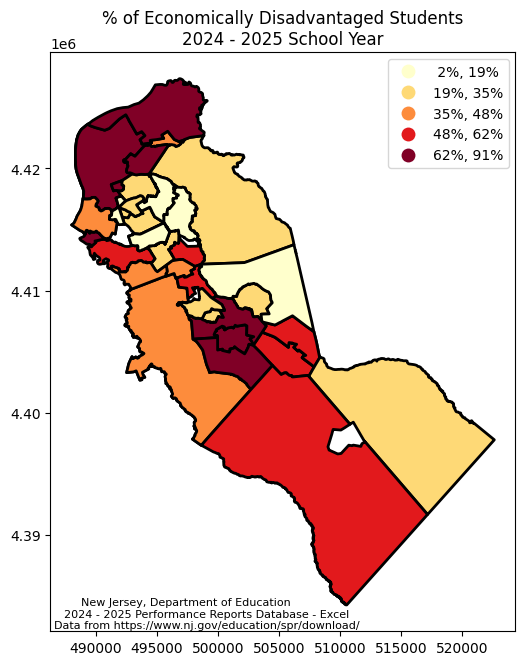

In [19]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )